Removed properties above 1000000.0 AED to remove outliers.


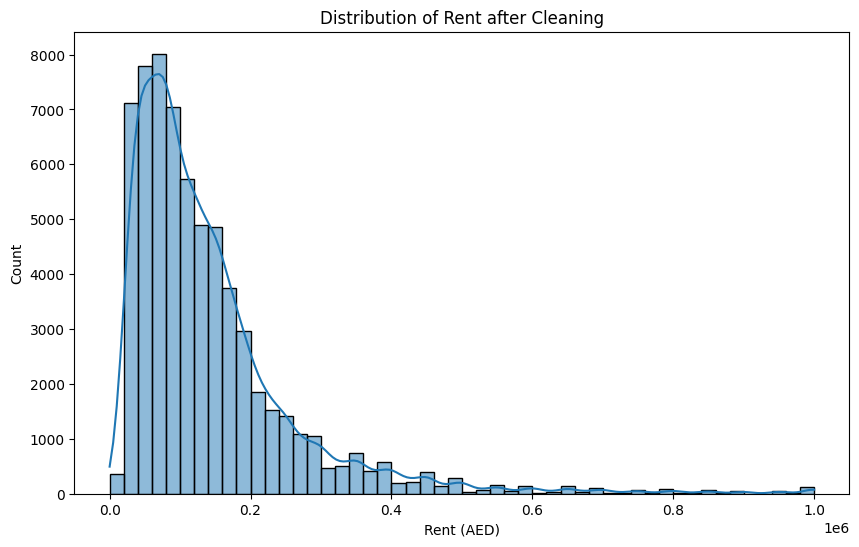


Cleaning Complete. New dataset shape: (64693, 15)
                 Rent          Beds         Baths   Area_in_sqft  \
count    64693.000000  64693.000000  64693.000000   64693.000000   
mean    143598.438255      2.415547      2.807831    2181.396967   
std     125380.109688      1.433051      1.660073    2797.408044   
min          1.000000      1.000000      1.000000      74.000000   
25%      65000.000000      1.000000      2.000000     983.000000   
50%     110000.000000      2.000000      2.000000    1460.000000   
75%     180000.000000      3.000000      3.000000    2280.000000   
max    1000000.000000     12.000000     11.000000  210254.000000   

       Rent_per_sqft  Age_of_listing_in_days  
count   64693.000000            64693.000000  
mean       85.083277               75.246163  
std        62.223250               71.319013  
min         0.000556               11.000000  
25%        37.681159               31.000000  
50%        69.238378               53.000000  
75%    

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (replace with your actual filename)
df = pd.read_csv('./data/dubai_properties.csv')

# --- STEP 1: Remove obvious errors ---
# Remove rows where Rent is 0 or Beds is 0 (impossible for a rental)
df = df[(df['Rent'] > 0) & (df['Beds'] > 0)]

# --- STEP 2: Handle Outliers using the IQR Method ---
# We will remove the top 1% of the most expensive properties to avoid skewing the model
q_limit = df['Rent'].quantile(0.99)
df_cleaned = df[df['Rent'] <= q_limit]

print(f"Removed properties above {q_limit} AED to remove outliers.")

# --- STEP 3: Fill Missing Values ---
# For Latitude/Longitude, we can just drop them as they aren't essential for a basic price model
df_cleaned = df_cleaned.drop(columns=['Latitude', 'Longitude'])

# --- STEP 4: Quick Visualization to check the "Health" of the data ---
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Rent'], bins=50, kde=True)
plt.title('Distribution of Rent after Cleaning')
plt.xlabel('Rent (AED)')
plt.show()

print("\nCleaning Complete. New dataset shape:", df_cleaned.shape)
print(df_cleaned.describe())

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Select the features we want to use to predict Rent
# We exclude 'Address' because it's too unique, and 'Rent_category' because it's derived from Rent
features = ['Beds', 'Baths', 'Area_in_sqft', 'Type', 'Furnishing', 'City', 'Location']
X = df_cleaned[features]
y = df_cleaned['Rent']

# 2. Convert categorical text into numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=['Type', 'Furnishing', 'City', 'Location'])

# 3. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Scaling the numbers
# 'Area_in_sqft' is in the thousands, while 'Beds' is usually 1-5.
# Scaling ensures the model doesn't think the Area is 1000x more important just because the number is bigger.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully encoded and scaled!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Data successfully encoded and scaled!
Training set size: 51754 samples
Testing set size: 12939 samples


--- Linear Regression ---
Mean Absolute Error (MAE): 39911.11 AED
R-squared Score: 0.7085
--------------------
--- Random Forest ---
Mean Absolute Error (MAE): 19796.18 AED
R-squared Score: 0.8867
--------------------


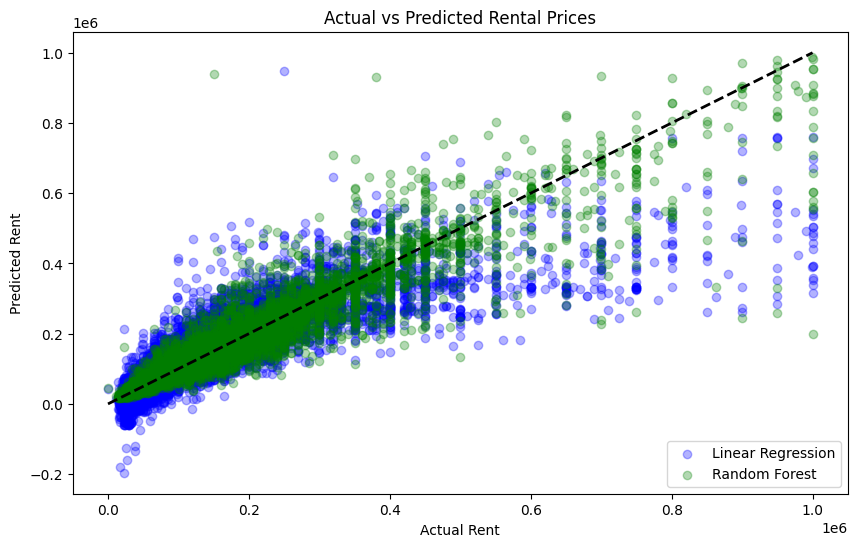

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# --- 1. Linear Regression (The Baseline) ---
# This model assumes a straight-line relationship between features and price
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# --- 2. Random Forest (The Powerhouse) ---
# This model uses hundreds of decision trees to find complex patterns
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# --- 3. Evaluation Metrics ---
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} AED")
    print(f"R-squared Score: {r2:.4f}")
    print("-" * 20)

evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest")

# --- 4. Visual Comparison ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_pred, alpha=0.3, label='Linear Regression', color='blue')
plt.scatter(y_test, rf_pred, alpha=0.3, label='Random Forest', color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted Rental Prices')
plt.legend()
plt.show()

In [14]:
def predict_my_rent(beds, baths, area, prop_type, furnishing, city, location):
    # 1. Create the input as a dictionary
    input_dict = {
        'Beds': [beds],
        'Baths': [baths],
        'Area_in_sqft': [area],
        'Type': [prop_type],
        'Furnishing': [furnishing],
        'City': [city],
        'Location': [location]
    }
    input_df = pd.DataFrame(input_dict)

    # 2. One-Hot Encode
    input_encoded = pd.get_dummies(input_df)

    # 3. Use a Reindex instead of a loop to fix the columns
    # This adds all missing columns as 0 and removes extra ones in one go
    input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

    # 4. Scale and Predict
    input_scaled = scaler.transform(input_encoded)
    prediction = rf_model.predict(input_scaled)

    return prediction[0]

# --- TEST IT AGAIN ---
price = predict_my_rent(2, 2, 1200, 'Apartment', 'Furnished', 'Abu Dhabi', 'Yas Island')
print(f"The predicted annual rent for this property is: {price:.2f} AED")

The predicted annual rent for this property is: 100421.65 AED
